## Compare booking ratio across neighborhoods

### Merge boking info with listings cleansed

In [82]:
import pandas as pd

In [70]:
bookings_df = pd.read_csv('data/listing_booking_info.csv')
bookings_df.head()

,Unnamed: 0,listing_id,total_days,unavailable_days,available_days,booking_ratio
0,0,2595,365,0,365,0.000000
1,1,6848,365,180,185,0.493151
2,2,6872,365,282,83,0.772603
3,3,6990,365,81,284,0.221918
4,4,7064,365,365,0,1.000000


In [71]:
listings_df = pd.read_csv('data/listings_cleansed_pi.csv')
listings_df.head()

,Unnamed: 0,id,name,description,neighborhood_overview,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month
0,0,2595.0,Skylit Midtown Castle Sanctuary,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,2845,9/9/08,within a day,90%,21%,...,4.68,4.73,4.63,4.77,4.80,4.81,4.40,f,3,0.27
1,1,6848.0,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,15991,5/6/09,within a few hours,100%,100%,...,4.58,4.59,4.85,4.85,4.80,4.69,4.58,f,1,1.04
2,2,6872.0,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,16104,5/7/09,a few days or more,30%,33%,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,f,2,0.03
3,3,6990.0,UES Beautiful Blue Room,Beautiful peaceful healthy home,"Location: Five minutes to Central Park, Museum...",16800,5/12/09,within an hour,100%,100%,...,4.88,4.83,4.95,4.96,4.95,4.85,4.85,f,1,1.37
4,4,7064.0,"Amazing location! Wburg. Large, bright & tranquil","Large, private loft-like room in a spacious 2-...","- One stop from the East Village, Lower East S...",17297,5/15/09,NaN,NaN,0%,...,4.91,5.00,4.91,5.00,5.00,5.00,5.00,f,2,0.08


In [72]:
listings_df.rename(columns={'id': 'listing_id'}, inplace=True)

In [73]:
merged_df = bookings_df.merge(listings_df[['listing_id', 'neighbourhood_cleansed']], on='listing_id', how='left')
merged_df.head()

,Unnamed: 0,listing_id,total_days,unavailable_days,available_days,booking_ratio,neighbourhood_cleansed
0,0,2595,365,0,365,0.000000,Midtown
1,1,6848,365,180,185,0.493151,Williamsburg
2,2,6872,365,282,83,0.772603,East Harlem
3,3,6990,365,81,284,0.221918,East Harlem
4,4,7064,365,365,0,1.000000,Williamsburg


In [74]:
booking_ratio_sorted = merged_df.sort_values(by='booking_ratio', ascending=False)

booking_ratio_sorted.head(20)

,Unnamed: 0,listing_id,total_days,unavailable_days,available_days,booking_ratio,neighbourhood_cleansed
23564,23564,662854742004200367,365,365,0,1.0,NaN
17937,17937,47036529,365,365,0,1.0,Upper East Side
9672,9672,21569360,365,365,0,1.0,Williamsburg
28050,28050,860474038279127366,365,365,0,1.0,NaN
20545,20545,52823346,365,365,0,1.0,Ridgewood
9676,9676,21580765,365,365,0,1.0,Bedford-Stuyvesant
9677,9677,21581457,365,365,0,1.0,Prospect Heights
20544,20544,52823283,365,365,0,1.0,Flushing
9679,9679,21583472,365,365,0,1.0,Bedford-Stuyvesant
9680,9680,21588023,365,365,0,1.0,Bedford-Stuyvesant


### Plot a Bar Chart of Booking Ratio of top 20 Neighborhoods

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# Drop NaN values in 'neighbourhood_cleansed'
df_filtered = merged_df.dropna(subset=['neighbourhood_cleansed'])

# Aggregate booking ratio per neighborhood (if not already computed)
booking_ratio = df_filtered.groupby('neighbourhood_cleansed')['booking_ratio'].mean().reset_index()

# Sort by booking ratio for better visualization
booking_ratio_sorted = booking_ratio.sort_values(by='booking_ratio', ascending=False).reset_index(drop=True)

booking_ratio_sorted = booking_ratio_sorted[booking_ratio_sorted['booking_ratio'] <= 0.7]

booking_ratio_sorted=booking_ratio_sorted.head(20)

/var/folders/hd/bjwby9bd7jx83jd4dhqqp7fc0000gn/T/ipykernel_17569/1961833321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=booking_ratio_sorted, x='neighbourhood_cleansed', y='booking_ratio', palette='Blues_r')


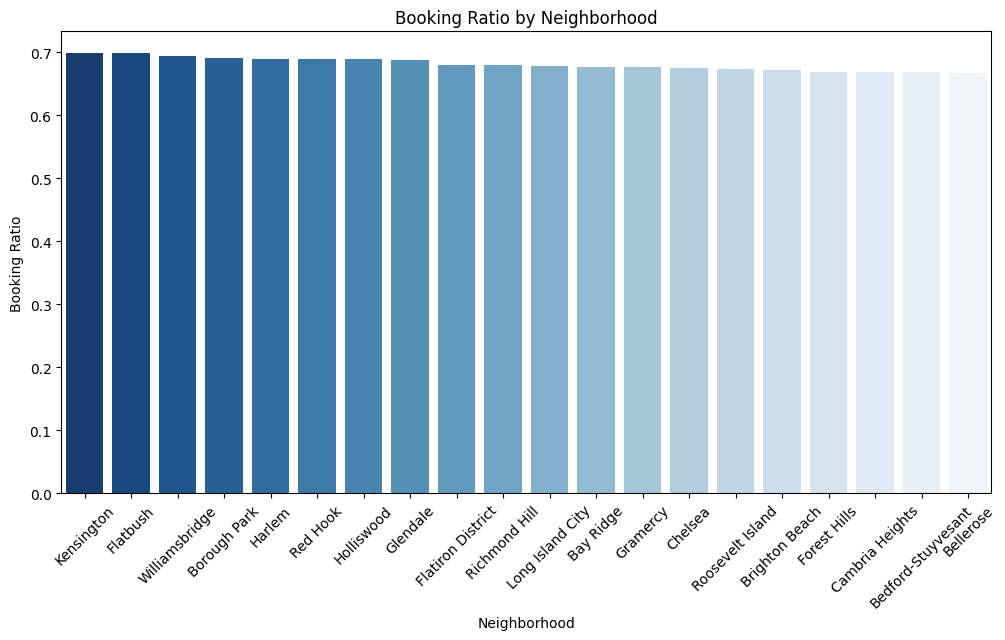

In [77]:
plt.figure(figsize=(12, 6))
sns.barplot(data=booking_ratio_sorted, x='neighbourhood_cleansed', y='booking_ratio', palette='Blues_r')

plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.xlabel('Neighborhood')
plt.ylabel('Booking Ratio')
plt.title('Booking Ratio by Neighborhood')
plt.show()

### Scatter Plot

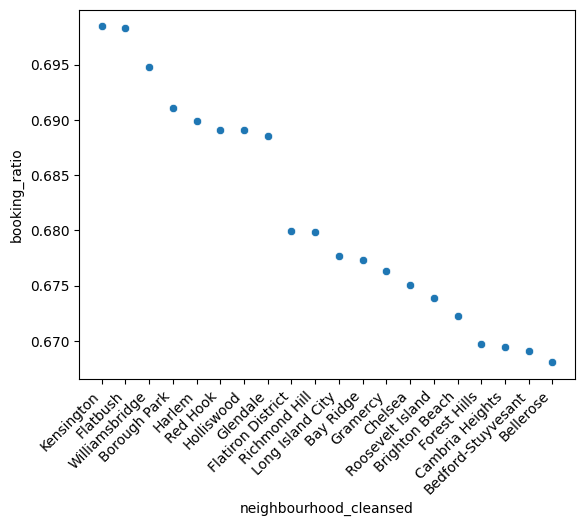

In [78]:
sns.scatterplot(data=booking_ratio_sorted, x='neighbourhood_cleansed', y='booking_ratio')
plt.xticks(rotation=45, ha='right') 
plt.show()

In [79]:
## use booking ratio to compare listing features - reviews, amenities,
# pycarat model - to evaluate performance feaatures 
# svm model, random forest

In [80]:
merged_df_listings = listings_df.merge(bookings_df[['listing_id', 'booking_ratio']], on='listing_id', how='left')
merged_df_listings.head()

,Unnamed: 0,listing_id,name,description,neighborhood_overview,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month,booking_ratio
0,0,2595.0,Skylit Midtown Castle Sanctuary,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,2845,9/9/08,within a day,90%,21%,...,4.73,4.63,4.77,4.80,4.81,4.40,f,3,0.27,0.000000
1,1,6848.0,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,15991,5/6/09,within a few hours,100%,100%,...,4.59,4.85,4.85,4.80,4.69,4.58,f,1,1.04,0.493151
2,2,6872.0,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,16104,5/7/09,a few days or more,30%,33%,...,5.00,5.00,5.00,5.00,5.00,5.00,f,2,0.03,0.772603
3,3,6990.0,UES Beautiful Blue Room,Beautiful peaceful healthy home,"Location: Five minutes to Central Park, Museum...",16800,5/12/09,within an hour,100%,100%,...,4.83,4.95,4.96,4.95,4.85,4.85,f,1,1.37,0.221918
4,4,7064.0,"Amazing location! Wburg. Large, bright & tranquil","Large, private loft-like room in a spacious 2-...","- One stop from the East Village, Lower East S...",17297,5/15/09,NaN,NaN,0%,...,5.00,4.91,5.00,5.00,5.00,5.00,f,2,0.08,1.000000


In [81]:
merged_df_listings.to_csv('data/bookings_listings_merged.csv')